# 🏦 Multinomial Logistic Regression using HDFC Loan Dataset

## Objective
This notebook demonstrates **Multinomial Logistic Regression** using a real-world
loan dataset.

### You will learn:
- What Multinomial Logistic Regression is
- When and why it is used
- How to convert loan data into a multiclass classification problem
- Model training, evaluation, and interpretation
- Practice through solved and unsolved exercises


## 📘 Logistic Regression Overview

Logistic Regression is a **supervised classification algorithm**.

### Types:
1. **Binary Logistic Regression**
   - Two classes (Approved / Rejected)
2. **Multinomial Logistic Regression**
   - More than two classes (Low / Medium / High Risk)
3. **Ordinal Logistic Regression**
   - Ordered classes

In this notebook, we focus on **Multinomial Logistic Regression**.


## 🧠 When to Use Multinomial Logistic Regression

Use Multinomial Logistic Regression when:
- Target variable has **more than two categories**
- Categories are **mutually exclusive**
- No natural order is assumed

### Real-world examples:
- Loan risk classification: Low / Medium / High
- Customer segmentation: Basic / Premium / Enterprise
- Credit rating: Poor / Average / Good


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/hdfc_loan_dataset_full_enriched.csv")
df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


## 📊 Dataset Overview

This dataset contains enriched loan application data including:
- Applicant income
- Credit history / score
- Loan amount
- Loan term
- Employment details
- Demographic & financial indicators

We will **derive a multiclass target variable** to model loan risk.


In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   object 
 1   Bank                         1000 non-null   object 
 2   Customer_Name                1000 non-null   object 
 3   Gender                       1000 non-null   object 
 4   Married                      1000 non-null   object 
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   object 
 7   Employment_Status            1000 non-null   object 
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area      

,0
Loan_ID,0
Bank,0
Customer_Name,0
Gender,0
Married,0
Dependents,0
Education,0
Employment_Status,0
Applicant_Income,0
Coapplicant_Income,0


## 🎯 Creating a Multiclass Target

Multinomial Logistic Regression requires **3 or more classes**.

We will create a **Loan Risk Category** based on:
- CIBIL Score
- Debt-to-Income Ratio
- Loan Amount

Risk Classes:
- **Low Risk**
- **Medium Risk**
- **High Risk**


In [9]:
def loan_risk(row):
    if row['CIBIL_Score'] >= 750 and row['Debt_to_Income_Ratio'] < 30:
        return 'Low_Risk'
    elif row['CIBIL_Score'] >= 650 and row['Debt_to_Income_Ratio'] < 45:
        return 'Medium_Risk'
    else:
        return 'High_Risk'

df['Loan_Risk'] = df.apply(loan_risk, axis=1)
df['Loan_Risk'].value_counts()

,count
Loan_Risk,
High_Risk,478
Medium_Risk,426
Low_Risk,96


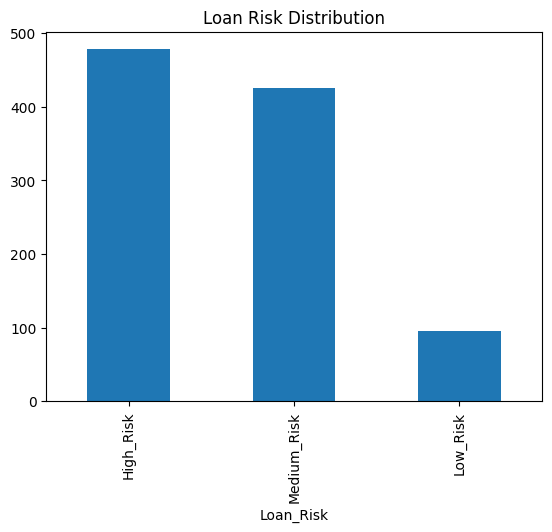

In [10]:
df['Loan_Risk'].value_counts().plot(kind='bar', title='Loan Risk Distribution')
plt.show()

## 🔧 Feature Selection

We will use the following features:
- Applicant_Income
- Loan_Amount
- Loan_Term
- CIBIL_Score
- Debt_to_Income_Ratio
- Employment_Length_Years

Target variable:
➡️ `Loan_Risk`


In [11]:
features = [
    'Applicant_Income',
    'Loan_Amount',
    'Loan_Term_Months',
    'CIBIL_Score',
    'Debt_to_Income_Ratio',
    'Employment_Length_Years'
]

X = df[features]
y = df['Loan_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [13]:
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

confusion_matrix(y_test, y_pred)

Accuracy: 0.99

Classification Report:
               precision    recall  f1-score   support

   High_Risk       0.99      1.00      0.99        96
    Low_Risk       1.00      0.95      0.97        19
 Medium_Risk       0.99      0.99      0.99        85

    accuracy                           0.99       200
   macro avg       0.99      0.98      0.99       200
weighted avg       0.99      0.99      0.99       200



array([[96,  0,  0],
       [ 0, 18,  1],
       [ 1,  0, 84]])

# ✍️ UNSOLVED PRACTICE EXERCISES

## 🧠 Exercise 1
Redefine loan risk categories using **Loan Amount** instead of Debt-to-Income.
Re-train the model and compare accuracy.


In [32]:
def loan_risk_v2(row):
    if row['CIBIL_Score'] >= 750 and row['Loan_Amount'] < 200000:
        return 'Low_Risk'
    elif row['CIBIL_Score'] >= 650 and row['Loan_Amount'] < 500000:
        return 'Medium_Risk'
    else:
        return 'High_Risk'

df['Loan_Risk_v2'] = df.apply(loan_risk_v2, axis=1)
df

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation,Loan_Risk,Loan_Risk_v2
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer,Medium_Risk,High_Risk
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer,Medium_Risk,High_Risk
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative,High_Risk,High_Risk
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive,Medium_Risk,High_Risk
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper,High_Risk,High_Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,HDFC100996,HDFC Bank,Simran Kaur,Male,Yes,1,Graduate,Salaried,44713,0,...,Sikh,Tamil Nadu,Coimbatore,6635,3.830000e+11,9350952889,simran.kaur@example.in,Medical Representative,Medium_Risk,High_Risk
996,HDFC100997,HDFC Bank,Krishna Mehta,Male,No,2,Graduate,Salaried,70886,0,...,Hindu,Kerala,Trivandrum,217843,7.040000e+11,9176504718,krishna.mehta@example.in,Customer Support Executive,High_Risk,High_Risk
997,HDFC100998,HDFC Bank,Rohan Verma,Female,No,1,Graduate,Salaried,24392,11337,...,Hindu,Delhi,New Delhi,89211,9.954289e+10,9966866798,rohan.verma@example.in,Driver,Medium_Risk,Medium_Risk
998,HDFC100999,HDFC Bank,Ananya Joshi,Female,No,2,Graduate,Salaried,64803,94136,...,Hindu,Gujarat,Ahmedabad,532976,6.170000e+11,9103847156,ananya.joshi@example.in,Electrician,Medium_Risk,High_Risk


In [31]:
y = df['Loan_Risk_v2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.92


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 🧠 Exercise 2
Train the model using only:
- Credit_Score
- Debt_to_Income
- Employment_Years

Compare performance with the full-feature model.


In [27]:
features_small = [
    'CIBIL_Score',
    'Debt_to_Income_Ratio',
    'Employment_Length_Years'
]

X_small = df[features_small]
y = df['Loan_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy (Reduced Features):", accuracy_score(y_test, y_pred))

Accuracy (Reduced Features): 0.99


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 🧠 Exercise 3
Plot a confusion matrix heatmap and analyze:
- Which risk category is hardest to predict?
- Why?


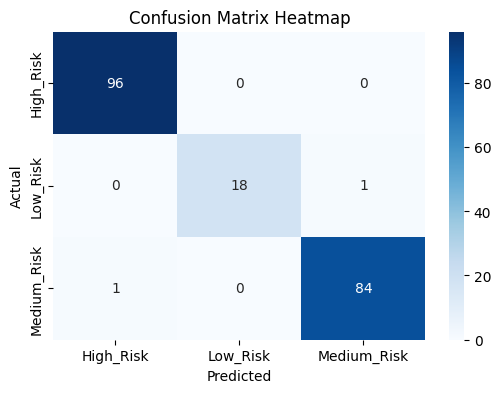

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

## 🧠 Exercise 4
Experiment with different solvers:
- `lbfgs`
- `newton-cg`
- `sag`

Compare convergence time and accuracy.


In [24]:
solvers = ['lbfgs', 'newton-cg', 'sag']

for solver in solvers:
    model = LogisticRegression(
        multi_class='multinomial',
        solver=solver,
        max_iter=1000
    )

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    print(f"\nSolver: {solver}")
    print("Accuracy:", accuracy_score(y_test, y_pred))


Solver: lbfgs
Accuracy: 0.99

Solver: newton-cg
Accuracy: 0.99

Solver: sag
Accuracy: 0.99


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
